# Co-occurrence Networks of Occupations for Astronomers

This notebook computes co-occurrence networks of occupations for individuals classified as astronomers in three historical time periods (750--1250, 1400--1650, 1750--1950). For each period, the top 15 most frequent co-occupations are selected and their pairwise co-occurrence on the same individual is visualised as a network graph. Node size encodes occupation frequency and edge width encodes co-occurrence strength.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Query astronomer records and build co-occurrence counts

Fetch all individuals whose occupations include "astronomer", bin them into three periods by impact date, and count individual occupation frequencies and pairwise co-occurrences. Variant spellings (amateur astronomer, radio astronomer, etc.) are excluded from the co-occupation list.

In [ ]:
import duckdb
import polars as pl
from collections import Counter
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

DB = DB_PATH
conn = duckdb.connect(DB, read_only=True)

# --- Display raw extracted data as DataFrame ---
query = """
    SELECT i.occupations_en,
           d.floruit_period_start
    FROM individuals i
    JOIN individuals_floruit_period d ON i.wikidata_id = d.wikidata_id
    WHERE i.occupations_en LIKE '%astronomer%'
      AND d.floruit_period_start IS NOT NULL
"""
df_raw = conn.execute(query).pl()
print(f"Extracted {df_raw.height:,} astronomer records")
df_raw.head(20)

In [3]:
df_raw

,occupations_en,floruit_period_start
0,astronomer,1959
1,astronomer; mathematician; civil servant; writ...,1802
2,astronomer; pedagogue; mathematician; physicia...,1595
3,astronomer; writer,1897
4,astronomer; mathematician; military officer; w...,1876
...,...,...
9249,astronomer,1986
9250,astronomer; university teacher; chief of polic...,1881
9251,astronomer,1830
9252,astronomer; pedagogue; writer; teacher,1953


In [ ]:

# --- Process into co-occurrence counts ---
astronomer_variants = {'amateur astronomer', 'radio astronomer',
                       'archaeoastronomer', 'astronomer royal'}

periods = {
    '750 – 1250':  (750, 1250),
    '1400 – 1650': (1400, 1650),
    '1750 – 1950': (1750, 1950),
}

occ_counts = {name: Counter() for name in periods}
pair_counts = {name: Counter() for name in periods}
n_astro = {name: 0 for name in periods}

for row in df_raw.iter_rows(named=True):
    occs_str = row['occupations_en']
    year = row['floruit_period_start']
    if year is None:
        continue
    for name, (y0, y1) in periods.items():
        if y0 <= year <= y1:
            n_astro[name] += 1
            occs = [o.strip() for o in occs_str.split('; ')
                    if o.strip() and o.strip().lower() not in astronomer_variants]
            for occ in occs:
                occ_counts[name][occ] += 1
            for a, b in combinations(sorted(occs), 2):
                pair_counts[name][(a, b)] += 1
            break

conn.close()

for name in periods:
    print(f"{name}: {n_astro[name]} astronomers, "
          f"{len(occ_counts[name])} unique occupations, "
          f"{len(pair_counts[name])} unique pairs")

## Plot the three-panel co-occurrence network

For each period, select the top 15 occupations (always including "astronomer"), build a graph with edges weighted by co-occurrence count (minimum 2), and draw it with a spring layout. The astronomer node is highlighted in blue; labels show occupation name and its share among astronomers in that period.

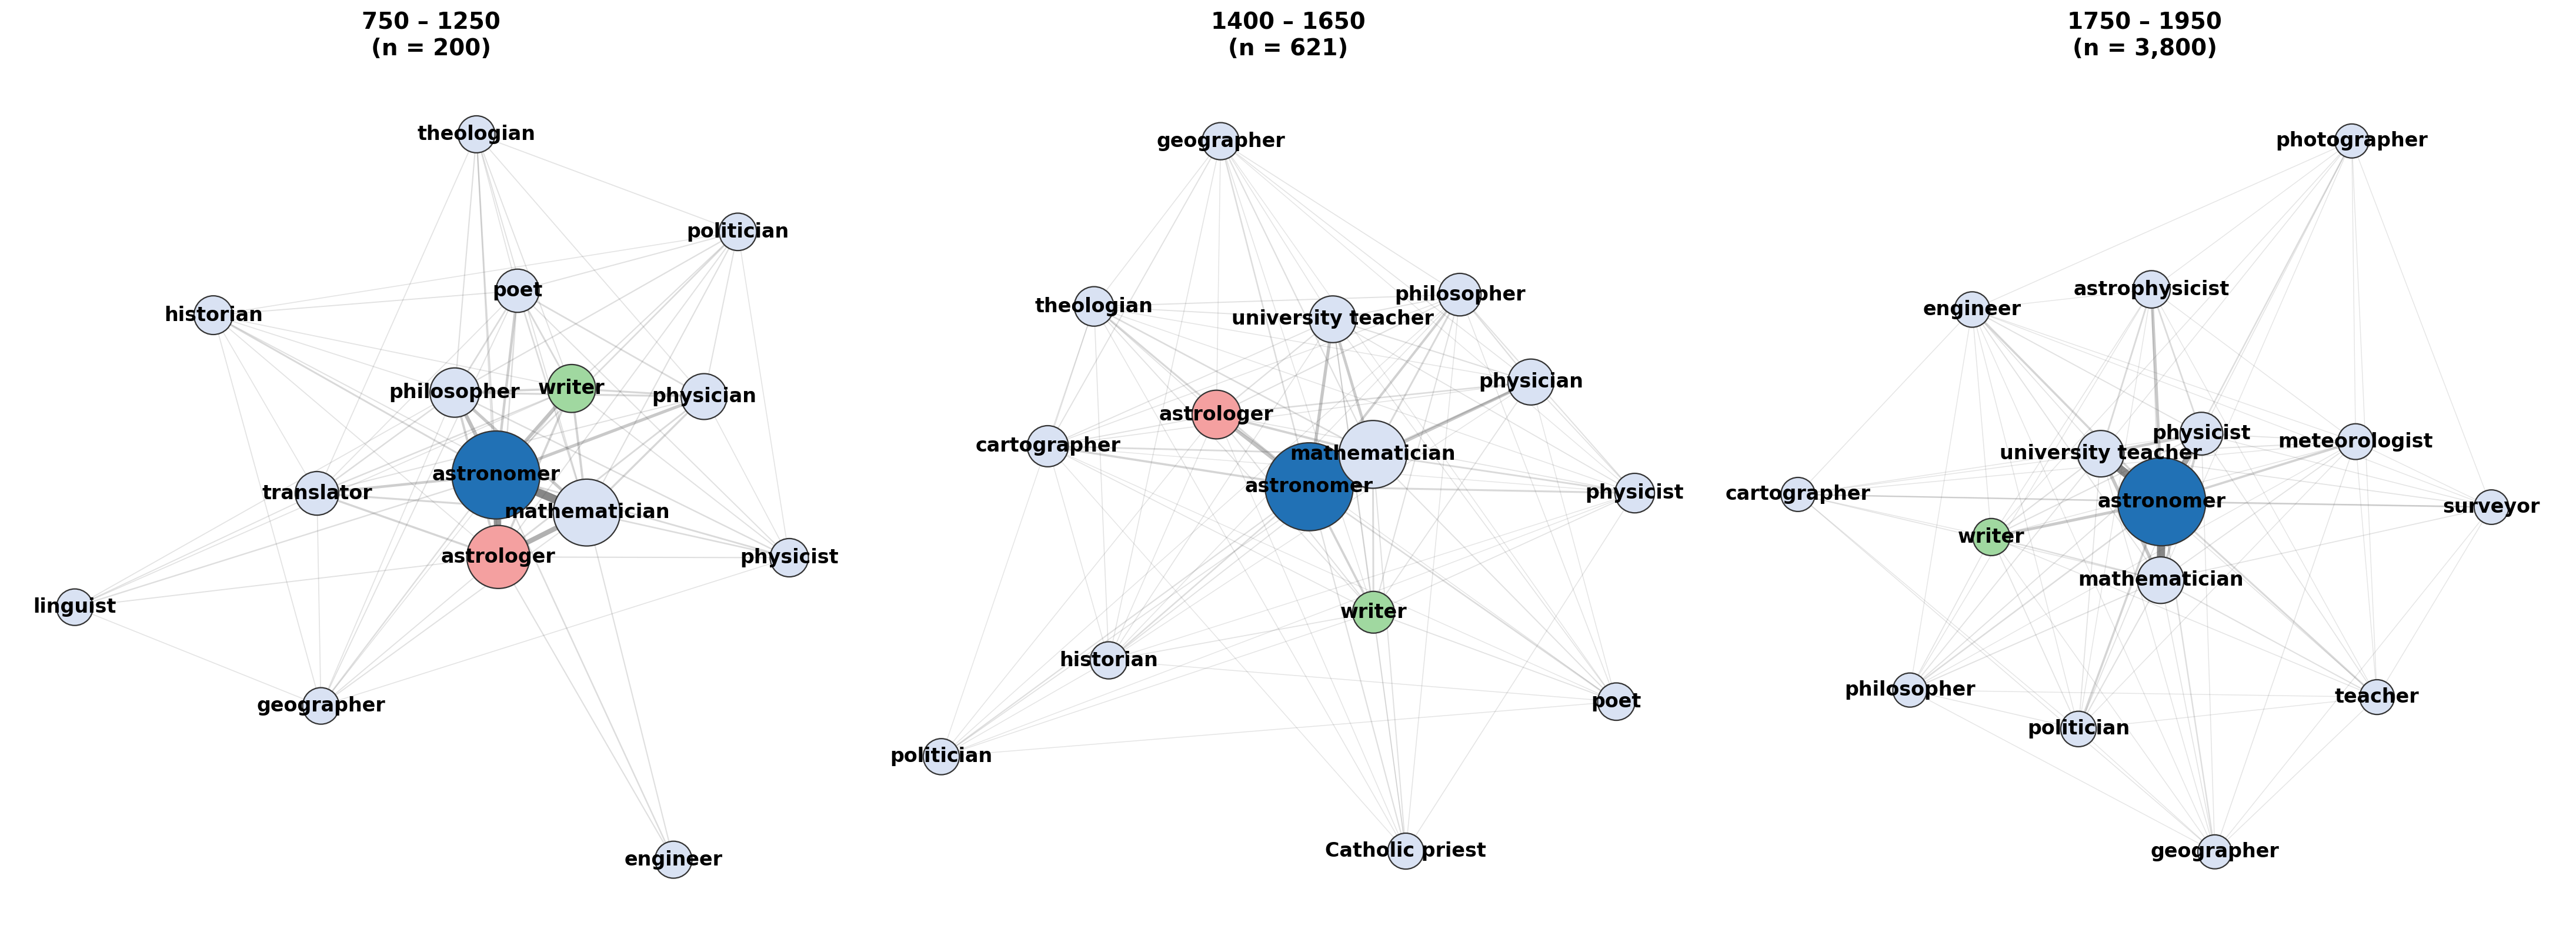

In [5]:
N_NODES = 15

fig, axes = plt.subplots(1, 3, figsize=(22, 8), dpi=200)

for ax, name in zip(axes, periods):
    top_occs = [occ for occ, _ in occ_counts[name].most_common(N_NODES)]
    if 'astronomer' not in top_occs:
        top_occs = ['astronomer'] + top_occs[:N_NODES - 1]
    top_set = set(top_occs)

    G = nx.Graph()
    for occ in top_occs:
        G.add_node(occ, count=occ_counts[name][occ])

    for (a, b), cnt in pair_counts[name].items():
        if a in top_set and b in top_set and cnt >= 2:
            G.add_edge(a, b, weight=cnt)

    pos = nx.spring_layout(G, k=2.0, iterations=150, seed=42, weight='weight')

    counts = [G.nodes[n]['count'] for n in G.nodes()]
    max_c = max(counts)
    node_sizes = [400 + 2500 * (c / max_c) for c in counts]

    # Color: astronomer=blue, astrologer=light red, writer=light green, rest=light blue
    node_colors = []
    for n in G.nodes():
        if n == 'astronomer':
            node_colors.append('#2171b5')
        elif n == 'astrologer':
            node_colors.append('#f4a0a0')
        elif n == 'writer':
            node_colors.append('#a0d8a0')
        else:
            node_colors.append('#d9e2f3')

    if G.edges():
        edge_weights = [G.edges[e]['weight'] for e in G.edges()]
        max_ew = max(edge_weights)
        edge_widths = [0.5 + 4.5 * (w / max_ew) for w in edge_weights]
        edge_alphas = [0.15 + 0.55 * (w / max_ew) for w in edge_weights]
    else:
        edge_widths, edge_alphas = [], []

    for (u, v), ew, ea in zip(G.edges(), edge_widths, edge_alphas):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax,
                               width=ew, edge_color='#555555', alpha=ea)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, edgecolors='#333333',
                           linewidths=0.8)

    # Labels: no %, all in black, bigger font
    all_labels = {}
    for occ in G.nodes():
        all_labels[occ] = occ

    nx.draw_networkx_labels(G, pos, labels=all_labels, ax=ax, font_size=12,
                            font_color='black', font_weight='bold')

    ax.set_title(f"{name}\n(n = {n_astro[name]:,})", fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

plt.tight_layout()
plt.show()